# 用平行四邊形直覺理解特徵值

特徵向量 / 對角化（Eigen Decomposition）

目標：
1. 用兩個向量 v1, v2 組成一個平行四邊形。
2. 選一個矩陣 A，觀察 A 對平行四邊形的作用（通常會扭曲/剪切）。
3. 計算 A 的特徵值與特徵向量。
4. 用「特徵向量當作邊」再做一次，會看到「只沿兩個方向單純拉伸」——這就是對角化的幾何直覺。

注意：本 Notebook 只提供程式碼，執行後你會看到圖形與數值輸出。
"""

In [14]:
import numpy as np
import matplotlib.pyplot as plt

## 0. 小工具：畫向量與平行四邊形

- 向量：從原點畫出一支箭頭
- 平行四邊形：由兩個邊向量 v1, v2 張成
  四個頂點是：0, v1, v2, v1+v2

In [15]:
def plot_vector(ax, v, label=None, **kwargs):
    ax.arrow(
        0, 0, v[0], v[1],
        length_includes_head=True,
        head_width=0.08,
        head_length=0.12,
        **kwargs
    )
    if label is not None:
        ax.text(v[0]*1.03, v[1]*1.03, label, fontsize=11)

def plot_parallelogram(ax, v1, v2, label=None, **kwargs):
    O = np.array([0.0, 0.0])
    P1 = v1
    P2 = v2
    P3 = v1 + v2
    poly = np.vstack([O, P1, P3, P2, O])
    ax.plot(poly[:, 0], poly[:, 1], **kwargs)
    if label is not None:
        # 放在中心附近
        C = (P1 + P2) / 2
        ax.text(C[0], C[1], label, fontsize=11)

def setup_axes(ax, title="", lim=4.0):
    ax.set_title(title)
    ax.set_aspect("equal", adjustable="box")
    ax.axhline(0, linewidth=1)
    ax.axvline(0, linewidth=1)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.grid(True, alpha=0.3)


## 1. 定義兩個向量，組成平行四邊形

你可以隨意改 v1, v2（只要不要共線）。

In [16]:
v1 = np.array([2.0, 0.5])
v2 = np.array([0.7, 1.8])

## 2. 定義矩陣 A（刻意選一個會「扭曲」的例子）

這個 A 會讓一般平行四邊形產生剪切/扭曲，方便看出「一般情況不是單純拉伸」。

In [17]:
A = np.array([
    [2.0, 1.0],
    [1.0, 2.0]
])

## 3. 先畫：原本的平行四邊形（由 v1, v2 張成）

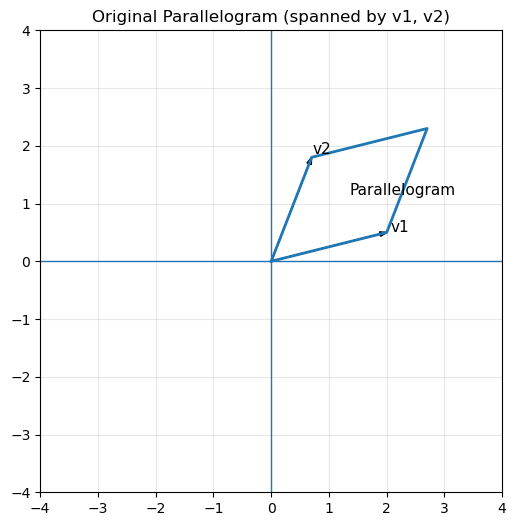

In [18]:
fig, ax = plt.subplots(figsize=(6, 6))
setup_axes(ax, title="Original Parallelogram (spanned by v1, v2)", lim=4)

plot_vector(ax, v1, label="v1")
plot_vector(ax, v2, label="v2")
plot_parallelogram(ax, v1, v2, label="Parallelogram", linewidth=2)

plt.show()

## 4. 矩陣作用：A v1, A v2，平行四邊形被變形

對比：
- 原始：由 v1, v2 張成
- 變形後：由 Av1, Av2 張成

一般情況下，方向與形狀會被「扭曲」，不只是簡單放大縮小。

Av1: [4.5 3. ]
Av2: [3.2 4.3]


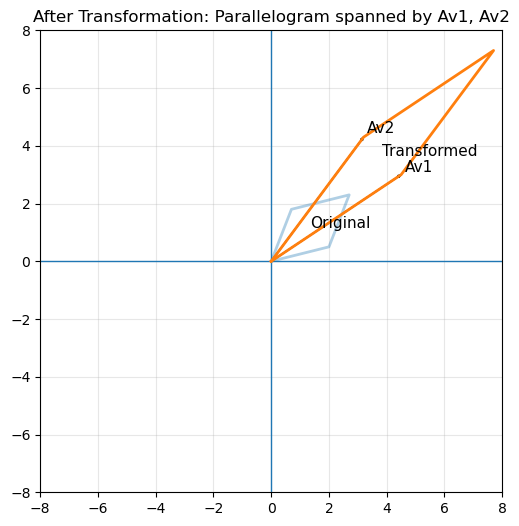

In [25]:
Av1 = A @ v1
Av2 = A @ v2

print("Av1:", Av1)
print("Av2:", Av2)

fig, ax = plt.subplots(figsize=(6, 6))
setup_axes(ax, title="After Transformation: Parallelogram spanned by Av1, Av2", lim=8)

# 原始（淡一點，方便比）
plot_parallelogram(ax, v1, v2, label="Original", linewidth=2, alpha=0.35)

# 變形後（重點）
plot_vector(ax, Av1, label="Av1")
plot_vector(ax, Av2, label="Av2")
plot_parallelogram(ax, Av1, Av2, label="Transformed", linewidth=2)

plt.show()

## 5. 計算特徵值與特徵向量

定義：
- 若 A v = λ v，則 v 是特徵向量、λ 是特徵值
- 幾何上：沿著特徵向量方向，矩陣只會「單純拉伸/縮放」（不改方向）

我們用 numpy.linalg.eig 計算。

In [20]:
eigvals, eigvecs = np.linalg.eig(A)

# eigvecs 的每一欄是對應的特徵向量
# 例如：eigvecs[:, 0] 對應 eigvals[0]
print("A =\n", A)
print("\nEigenvalues:\n", eigvals)
print("\nEigenvectors (columns):\n", eigvecs)

A =
 [[2. 1.]
 [1. 2.]]

Eigenvalues:
 [3. 1.]

Eigenvectors (columns):
 [[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]


## 6. 視覺化特徵向量方向

把兩個特徵向量畫在同一張圖上。
（注意：特徵向量可以乘任意非零常數，所以長度不重要，方向最重要）

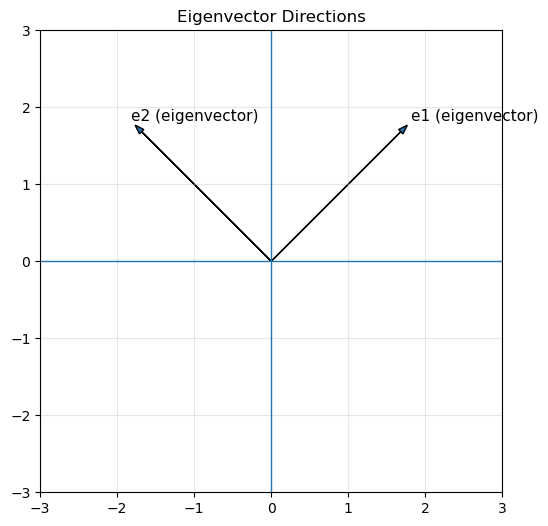

In [21]:
e1 = eigvecs[:, 0]
e2 = eigvecs[:, 1]

# 為了畫起來好看，把它們縮放到差不多長度
def normalize(v):
    return v / np.linalg.norm(v)

e1n = normalize(e1)
e2n = normalize(e2)

fig, ax = plt.subplots(figsize=(6, 6))
setup_axes(ax, title="Eigenvector Directions", lim=3)

plot_vector(ax, 2.5*e1n, label="e1 (eigenvector)")
plot_vector(ax, 2.5*e2n, label="e2 (eigenvector)")

plt.show()

## 7. 關鍵視覺：用特徵向量當作「平行四邊形的兩條邊」

想法：
- 你剛剛用 v1, v2 當邊，A 作用後會扭曲
- 現在改用「特徵向量」當邊：
  - 邊1：e1
  - 邊2：e2
- 由於 A e1 = λ1 e1、A e2 = λ2 e2，
  變形後的平行四邊形邊仍然沿著同方向，只是被 λ1、λ2 拉伸

這就是「單純拉伸」的視覺化。

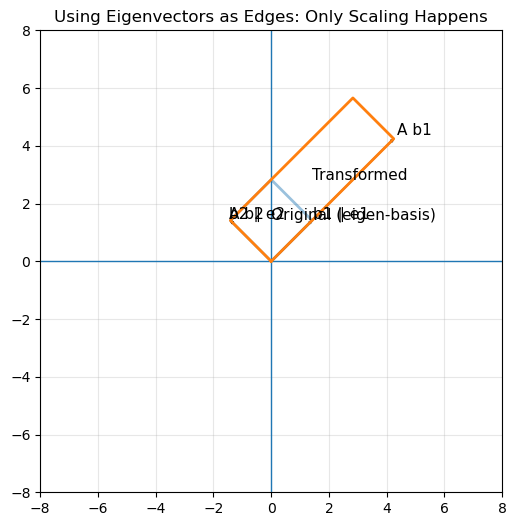

In [22]:
# 取特徵向量作為邊（縮放到視覺比較清楚）
b1 = 2.0 * e1n
b2 = 2.0 * e2n

Ab1 = A @ b1
Ab2 = A @ b2

fig, ax = plt.subplots(figsize=(6, 6))
setup_axes(ax, title="Using Eigenvectors as Edges: Only Scaling Happens", lim=8)

# 原本（特徵向量張的平行四邊形）
plot_parallelogram(ax, b1, b2, label="Original (eigen-basis)", linewidth=2, alpha=0.45)
plot_vector(ax, b1, label="b1 ∥ e1", alpha=0.7)
plot_vector(ax, b2, label="b2 ∥ e2", alpha=0.7)

# 作用後（仍沿相同方向，只是長度改變）
plot_parallelogram(ax, Ab1, Ab2, label="Transformed", linewidth=2)
plot_vector(ax, Ab1, label="A b1", alpha=0.9)
plot_vector(ax, Ab2, label="A b2", alpha=0.9)

plt.show()

## 8. 對角化（特徵分解）：A = P Λ P^{-1}

- P：把特徵向量排成矩陣（每一欄一個特徵向量）
- Λ：對角矩陣（對角線是對應特徵值）

在「特徵向量座標系」中，A 的作用就是 Λ：只在各軸做獨立縮放。

In [23]:
P = eigvecs
Lambda = np.diag(eigvals)
Pinv = np.linalg.inv(P)

print("P =\n", P)
print("\nLambda =\n", Lambda)
print("\nP^{-1} =\n", Pinv)

# 驗證：A 是否等於 P Λ P^{-1}
A_recon = P @ Lambda @ Pinv
print("\nReconstructed A (P @ Lambda @ P^{-1}) =\n", A_recon)
print("\nAllclose(A, reconstructed)?", np.allclose(A, A_recon))


P =
 [[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]

Lambda =
 [[3. 0.]
 [0. 1.]]

P^{-1} =
 [[ 0.70710678  0.70710678]
 [-0.70710678  0.70710678]]

Reconstructed A (P @ Lambda @ P^{-1}) =
 [[2. 1.]
 [1. 2.]]

Allclose(A, reconstructed)? True


## 9. 進一步直覺：在「特徵座標」裡看變換

任意向量 x，在特徵座標中的座標是：
- c = P^{-1} x

變換後 Ax 在特徵座標中的座標：
- P^{-1} (A x) = P^{-1} A P c = Λ c

也就是：
- 在特徵座標裡，Ax 只是把 c 的每個分量乘上對應特徵值
  （完全像高中一元一次函數 y=ax，只是現在每個軸各有一個 a）

下面用幾個點形成的「小平行四邊形雲」示意：
- 左：原座標下
- 右：特徵座標下（可以看到單純縮放）

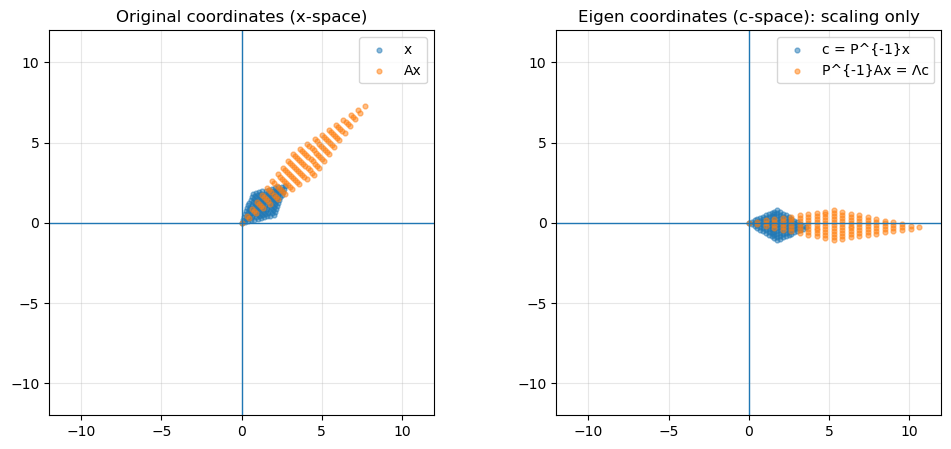

In [24]:
# 在原座標下，用 (v1, v2) 組成一堆點（小網格），看 A 作用
# 點形式：x = s*v1 + t*v2
s_vals = np.linspace(0, 1, 11)
t_vals = np.linspace(0, 1, 11)

points = []
for s in s_vals:
    for t in t_vals:
        points.append(s*v1 + t*v2)
points = np.array(points)  # shape (N, 2)

points_A = (A @ points.T).T

# 同一批點，換到特徵座標：c = P^{-1} x
points_eig = (Pinv @ points.T).T
points_eig_A = (Pinv @ points_A.T).T  # 或 Lambda @ points_eig.T

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

setup_axes(ax1, title="Original coordinates (x-space)", lim=12)
ax1.scatter(points[:, 0], points[:, 1], s=12, alpha=0.5, label="x")
ax1.scatter(points_A[:, 0], points_A[:, 1], s=12, alpha=0.5, label="Ax")
ax1.legend()

setup_axes(ax2, title="Eigen coordinates (c-space): scaling only", lim=12)
ax2.scatter(points_eig[:, 0], points_eig[:, 1], s=12, alpha=0.5, label="c = P^{-1}x")
ax2.scatter(points_eig_A[:, 0], points_eig_A[:, 1], s=12, alpha=0.5, label="P^{-1}Ax = Λc")
ax2.legend()

plt.show()


# 小結（你在圖上應該看到的重點）

1. 用一般 v1, v2 當邊：A 會把平行四邊形「扭曲」。
2. 用特徵向量當邊：A 只會把兩條邊各自拉伸（方向不變）。
3. 在特徵座標系中：A 變成對角矩陣 Λ，完全是「各軸獨立縮放」。

這就是特徵值（縮放倍數）與特徵向量（不改方向的軸）最直覺的幾何含義。